<a href="https://colab.research.google.com/github/Varun-Rahul-2007/ML---WEEKLY-LAB-ACTIVITY/blob/main/KNN_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 4: k-Nearest Neighbour (KNN) Classification on the Iris Dataset

**CSE 303 – Machine Learning**

**Aim:** Implement the k-Nearest Neighbour algorithm to classify the Iris dataset, using a Python ML library (scikit-learn). Print both the correct and the wrong predictions made by the model.

## 1. The Idea, in Plain English

Imagine Rahul walks into class late and doesn't know which "group" he belongs to for a seating arrangement. The simplest thing to do? **Look at the 5 students sitting closest to him** and put him in whichever group most of them belong to.

That is exactly what KNN does with data:

- Every flower in the Iris dataset is a point in space (based on its petal/sepal measurements).
- To classify a *new, unseen* flower, KNN looks at its **k nearest neighbours** (the k most similar flowers it has already seen).
- It takes a **majority vote** among those neighbours' species labels.
- Whichever species wins the vote becomes the prediction.

No training/fitting a curve happens here — KNN just *remembers* the data and does the comparison at prediction time. This is why it's called a **lazy learner**.

## 2. The Formal Idea

Given a new point $x$, and training data $\{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}$:

1. Compute the distance between $x$ and every training point $x_i$, typically the **Euclidean distance**:

$$d(x, x_i) = \sqrt{\sum_{j=1}^{m} (x_j - x_{ij})^2}$$

2. Pick the **k** training points with the smallest distance to $x$.
3. Assign $x$ the class label that occurs **most frequently** among those k neighbours.

**Choosing k matters:**
- Small k (e.g., 1) → very sensitive to noise, can overfit.
- Large k → smoother decision boundary, but can blur genuine class boundaries (underfit) and is more expensive to compute.
- k is usually chosen as an odd number (to avoid ties) and tuned via cross-validation.

## 3. The Dataset

The **Iris dataset** (built into scikit-learn) has 150 flower samples from 3 species:

| Feature | Description |
|---|---|
| Sepal Length (cm) | Length of the outer petal-like leaf |
| Sepal Width (cm)  | Width of the same |
| Petal Length (cm) | Length of the inner, true petal |
| Petal Width (cm)  | Width of the same |

**Target classes:** `Setosa`, `Versicolor`, `Virginica` — 50 samples each.

We'll pretend Ironman, Captain, Thor, and Hulk are the lab group measuring these flowers and building the classifier together.

## 4. Before You Start — Set Your Own Seed

To keep everyone's train/test split (and results) unique, **replace `ROLL_NUMBER` below with your own roll number** (as an integer). Do **not** use a shared seed like 42 — each of you should get a slightly different split and slightly different results.

In [ ]:
#  REPLACE THIS with your own roll number, e.g. 22 for roll no. AP22110011223
ROLL_NUMBER = 23

print(f"Using random seed = {ROLL_NUMBER}")

Using random seed = 23


## 5. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None

## 6. Load and Explore the Iris Dataset

In [ ]:
iris = load_iris()

X = iris.data                     # features: sepal/petal length & width
y = iris.target                   # target: 0 = setosa, 1 = versicolor, 2 = virginica
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

print("Shape of dataset:", df.shape)
print("\nClass distribution:")
print(df['species'].value_counts())

df.head(10)

Shape of dataset: (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


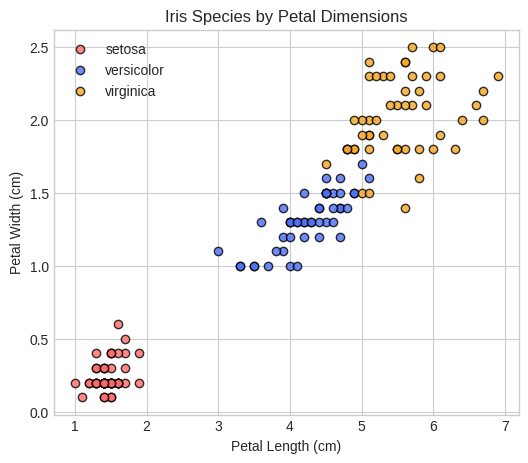

In [ ]:
# Quick visual check: petal length vs petal width, coloured by species
plt.figure(figsize=(6, 5))
colors = ['#FF6B6B', '#4C6EF5', '#F5A623']
for i, species in enumerate(target_names):
    subset = df[df['species'] == species]
    plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                label=species, color=colors[i], edgecolor='k', alpha=0.8)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Species by Petal Dimensions')
plt.legend()
plt.show()

## 7. Train-Test Split

We'll hold back 30% of the data to test the model on flowers it has never seen, using `ROLL_NUMBER` as the random seed.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=ROLL_NUMBER, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 105
Testing samples : 45


## 8. Worked Example — Classifying One Flower by Hand

Before letting scikit-learn do the heavy lifting, let's manually classify **one test flower** with k = 5, to see exactly what KNN is doing internally.

In [ ]:
# Take the first test flower
sample = X_test[0]
true_label = target_names[y_test[0]]

# Compute Euclidean distance from this sample to every training point
distances = np.sqrt(np.sum((X_train - sample) ** 2, axis=1))

# Find indices of the 5 nearest neighbours
k = 5
nearest_idx = np.argsort(distances)[:k]
nearest_labels = [target_names[y_train[i]] for i in nearest_idx]

print("Test flower measurements:", dict(zip(feature_names, sample.round(2))))
print("True species:", true_label)
print(f"\n{k} nearest neighbours' species:", nearest_labels)

# Majority vote
from collections import Counter
vote = Counter(nearest_labels).most_common(1)[0][0]
print(f"\nMajority vote prediction: {vote}")
print("Correct!" if vote == true_label else "Incorrect!")

Test flower measurements: {'sepal length (cm)': np.float64(5.0), 'sepal width (cm)': np.float64(3.5), 'petal length (cm)': np.float64(1.6), 'petal width (cm)': np.float64(0.6)}
True species: setosa

5 nearest neighbours' species: [np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa')]

Majority vote prediction: setosa
Correct!


In [ ]:
# Take the first test flower
sample = X_test[0]
true_label = target_names[y_test[0]]

# Compute Euclidean distance from this sample to every training point
distances = np.sqrt(np.sum((X_train - sample) ** 2, axis=1))

# Find indices of the 5 nearest neighbours
k = 1
nearest_idx = np.argsort(distances)[:k]
nearest_labels = [target_names[y_train[i]] for i in nearest_idx]

print("Test flower measurements:", dict(zip(feature_names, sample.round(2))))
print("True species:", true_label)
print(f"\n{k} nearest neighbours' species:", nearest_labels)

# Majority vote
from collections import Counter
vote = Counter(nearest_labels).most_common(1)[0][0]
print(f"\nMajority vote prediction: {vote}")
print("Correct!" if vote == true_label else "Incorrect!")

Test flower measurements: {'sepal length (cm)': np.float64(5.0), 'sepal width (cm)': np.float64(3.5), 'petal length (cm)': np.float64(1.6), 'petal width (cm)': np.float64(0.6)}
True species: setosa

1 nearest neighbours' species: [np.str_('setosa')]

Majority vote prediction: setosa
Correct!


In [ ]:
# Take the first test flower
sample = X_test[0]
true_label = target_names[y_test[0]]

# Compute Euclidean distance from this sample to every training point
distances = np.sqrt(np.sum((X_train - sample) ** 2, axis=1))

# Find indices of the 5 nearest neighbours
k = 3
nearest_idx = np.argsort(distances)[:k]
nearest_labels = [target_names[y_train[i]] for i in nearest_idx]

print("Test flower measurements:", dict(zip(feature_names, sample.round(2))))
print("True species:", true_label)
print(f"\n{k} nearest neighbours' species:", nearest_labels)

# Majority vote
from collections import Counter
vote = Counter(nearest_labels).most_common(1)[0][0]
print(f"\nMajority vote prediction: {vote}")
print("Correct!" if vote == true_label else "Incorrect!")

Test flower measurements: {'sepal length (cm)': np.float64(5.0), 'sepal width (cm)': np.float64(3.5), 'petal length (cm)': np.float64(1.6), 'petal width (cm)': np.float64(0.6)}
True species: setosa

3 nearest neighbours' species: [np.str_('setosa'), np.str_('setosa'), np.str_('setosa')]

Majority vote prediction: setosa
Correct!


In [ ]:
# Take the first test flower
sample = X_test[0]
true_label = target_names[y_test[0]]

# Compute Euclidean distance from this sample to every training point
distances = np.sqrt(np.sum((X_train - sample) ** 2, axis=1))

# Find indices of the 5 nearest neighbours
k = 9
nearest_idx = np.argsort(distances)[:k]
nearest_labels = [target_names[y_train[i]] for i in nearest_idx]

print("Test flower measurements:", dict(zip(feature_names, sample.round(2))))
print("True species:", true_label)
print(f"\n{k} nearest neighbours' species:", nearest_labels)

# Majority vote
from collections import Counter
vote = Counter(nearest_labels).most_common(1)[0][0]
print(f"\nMajority vote prediction: {vote}")
print("Correct!" if vote == true_label else "Incorrect!")

Test flower measurements: {'sepal length (cm)': np.float64(5.0), 'sepal width (cm)': np.float64(3.5), 'petal length (cm)': np.float64(1.6), 'petal width (cm)': np.float64(0.6)}
True species: setosa

9 nearest neighbours' species: [np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa')]

Majority vote prediction: setosa
Correct!


## 9. Building the KNN Classifier with scikit-learn

Now we let `KNeighborsClassifier` do this for every test sample at once, with k = 5.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Predictions generated for", len(y_pred), "test samples.")

Predictions generated for 45 test samples.


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn.fit(X_train, y_train)
#Their is no change in of accuracy when it changed to manhattan
y_pred = knn.predict(X_test)

print("Predictions generated for", len(y_pred), "test samples.")

Predictions generated for 45 test samples.


## 10. Printing Correct and Wrong Predictions

As required, we separate out every test sample into **correctly classified** and **wrongly classified**, showing the actual measurements, true species, and predicted species for each.

In [ ]:
results = pd.DataFrame(X_test, columns=feature_names)
results['Actual']    = [target_names[i] for i in y_test]
results['Predicted'] = [target_names[i] for i in y_pred]
results['Result']    = np.where(results['Actual'] == results['Predicted'], 'Correct', 'Wrong')

correct = results[results['Result'] == 'Correct'].reset_index(drop=True)
wrong   = results[results['Result'] == 'Wrong'].reset_index(drop=True)

print("=" * 70)
print(f"CORRECT PREDICTIONS ({len(correct)} out of {len(results)})")
print("=" * 70)
print(correct.to_string(index=True))

print("\n" + "=" * 70)
print(f"WRONG PREDICTIONS ({len(wrong)} out of {len(results)})")
print("=" * 70)
if len(wrong) > 0:
    print(wrong.to_string(index=True))
else:
    print("None — every test sample was classified correctly for this split/seed.")

CORRECT PREDICTIONS (42 out of 45)
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)      Actual   Predicted   Result
0                 5.0               3.5                1.6               0.6      setosa      setosa  Correct
1                 6.3               2.5                5.0               1.9   virginica   virginica  Correct
2                 5.5               2.4                3.7               1.0  versicolor  versicolor  Correct
3                 4.8               3.4                1.6               0.2      setosa      setosa  Correct
4                 7.9               3.8                6.4               2.0   virginica   virginica  Correct
5                 4.7               3.2                1.3               0.2      setosa      setosa  Correct
6                 5.6               2.8                4.9               2.0   virginica   virginica  Correct
7                 4.9               3.1                1.5               0.1      set

## 11. Model Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)\n")

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=[f"Actual {n}" for n in target_names],
                          columns=[f"Pred {n}" for n in target_names])
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9333  (93.33%)

Confusion Matrix:
                   Pred setosa  Pred versicolor  Pred virginica
Actual setosa               15                0               0
Actual versicolor            0               15               0
Actual virginica             0                3              12

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



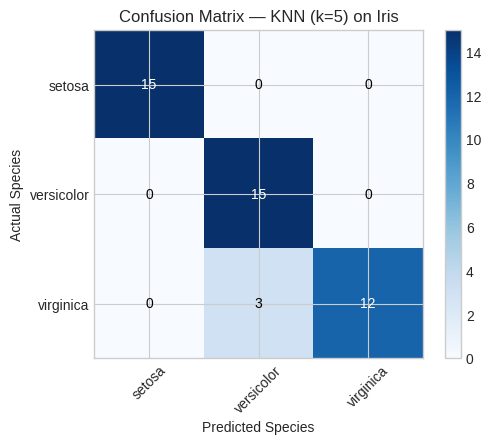

In [ ]:
# Visualise the confusion matrix
plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix — KNN (k=5) on Iris')
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 12. How Does Accuracy Change with k?

Let's check how test accuracy varies as we change the number of neighbours, k, from 1 to 15.

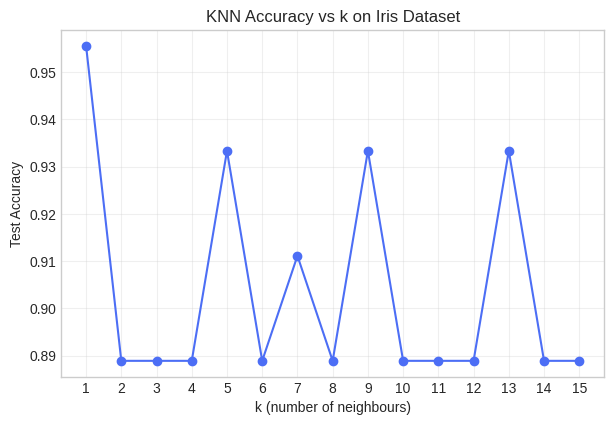

Best k for this split: 1  (Accuracy: 0.9556)


In [ ]:
k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_values), accuracies, marker='o', color='#4C6EF5')
plt.xlabel('k (number of neighbours)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs k on Iris Dataset')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(k_values)[int(np.argmax(accuracies))]
print(f"Best k for this split: {best_k}  (Accuracy: {max(accuracies):.4f})")

## 13. Lab Exercise (To Be Completed by Students)

1. Re-run the notebook with **your own roll number** as the seed (Section 4) — do NOT use 42.
2. Try k = 1, k = 3, and k = 9. How does the number of wrong predictions change?
3. Change the `metric` parameter of `KNeighborsClassifier` from `'euclidean'` to `'manhattan'`. Does accuracy change?
4. In Section 10, look at your **wrong predictions** (if any). Which two species are most often confused with each other, and why do you think that happens (hint: look at the confusion matrix)?

---
*End of Experiment 4.*